In [1]:
!curl -O https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
 99  786M   99  784M    0     0  16.9M      0  0:00:46  0:00:46 --:--:-- 17.5M

OSError: [Errno 5] Input/output error

In [5]:
import os
import numpy as np
import keras
import tensorflow as tf
import matplotlib.pyplot as plt

In [3]:
!unzip -q kagglecatsanddogs_5340.zip
!ls


replace PetImages/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C
advanced_image_classification.ipynb minst_classification.ipynb
CDLA-Permissive-2.0.pdf             PetImages
classification.ipynb                readme[1].txt
kagglecatsanddogs_5340.zip


In [6]:
num_skipped = 0
for folder_name in ("Cat", "Dog"):
    folder_path = os.path.join("PetImages", folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        try:
            fobj = open(fpath, "rb")
            is_jfif = b"JFIF" in fobj.peek(10)
        finally:
            fobj.close()

        if not is_jfif:
            num_skipped += 1
            # Delete corrupted image
            os.remove(fpath)

print(f"Deleted {num_skipped} images.")


Deleted 0 images.


In [7]:
image_shape = (180, 180, 3)
batch_size = 128

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    "PetImages",
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_shape[:2],
    batch_size=batch_size,
)


Found 23410 files belonging to 2 classes.
Using 18728 files for training.
Using 4682 files for validation.


2026-02-09 13:42:29.249783: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


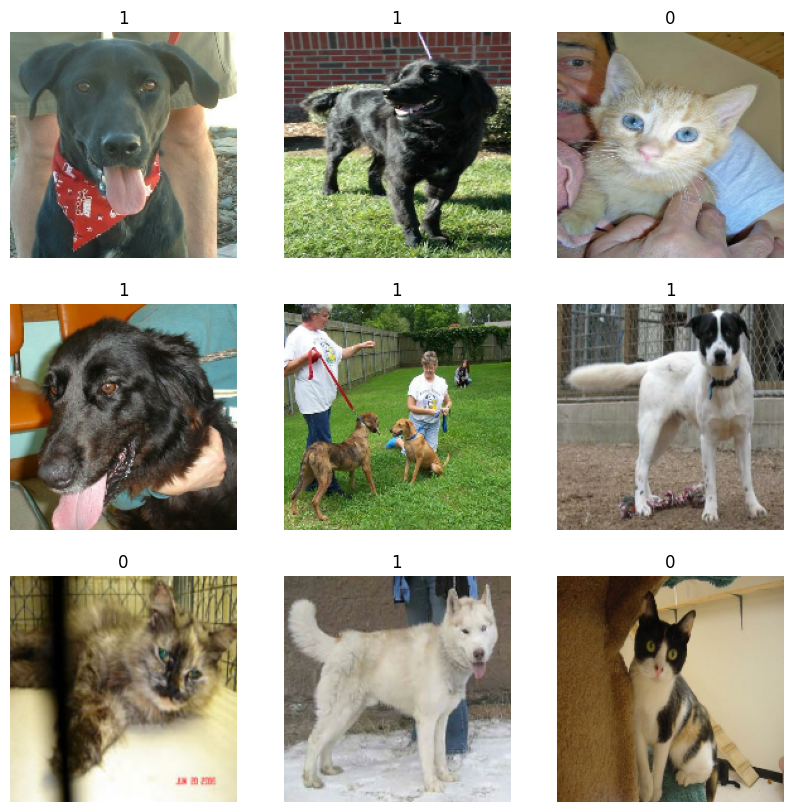

In [8]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(int(labels[i]))
        plt.axis("off")

In [9]:
data_augmentation_layers = [
    keras.layers.RandomFlip("horizontal"),      # Randomly flip (mirror) horizontally
    keras.layers.RandomRotation(0.1),           # Add a random rotation
]


def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images


2026-02-09 13:42:34.864210: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


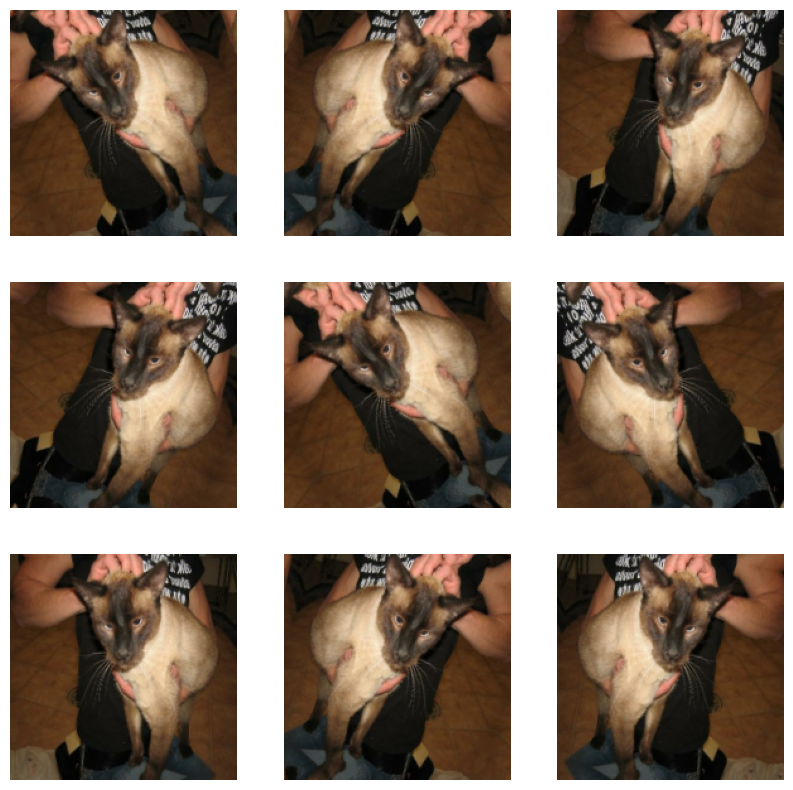

In [10]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(augmented_images[0]).astype("uint8"))
        plt.axis("off")


In [11]:
train_ds = train_ds.map(
    lambda img, label: (data_augmentation(img), label),
    num_parallel_calls=tf.data.AUTOTUNE,
)

In [12]:
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

In [13]:
sequential_model = keras.Sequential(
    [
        keras.Input(shape=image_shape),
        keras.layers.Rescaling(1.0/255),    # Standardise the images on-the-fly
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
        keras.layers.MaxPooling2D(pool_size=(2, 2)),
        keras.layers.Flatten(),
        keras.layers.Dropout(0.4),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

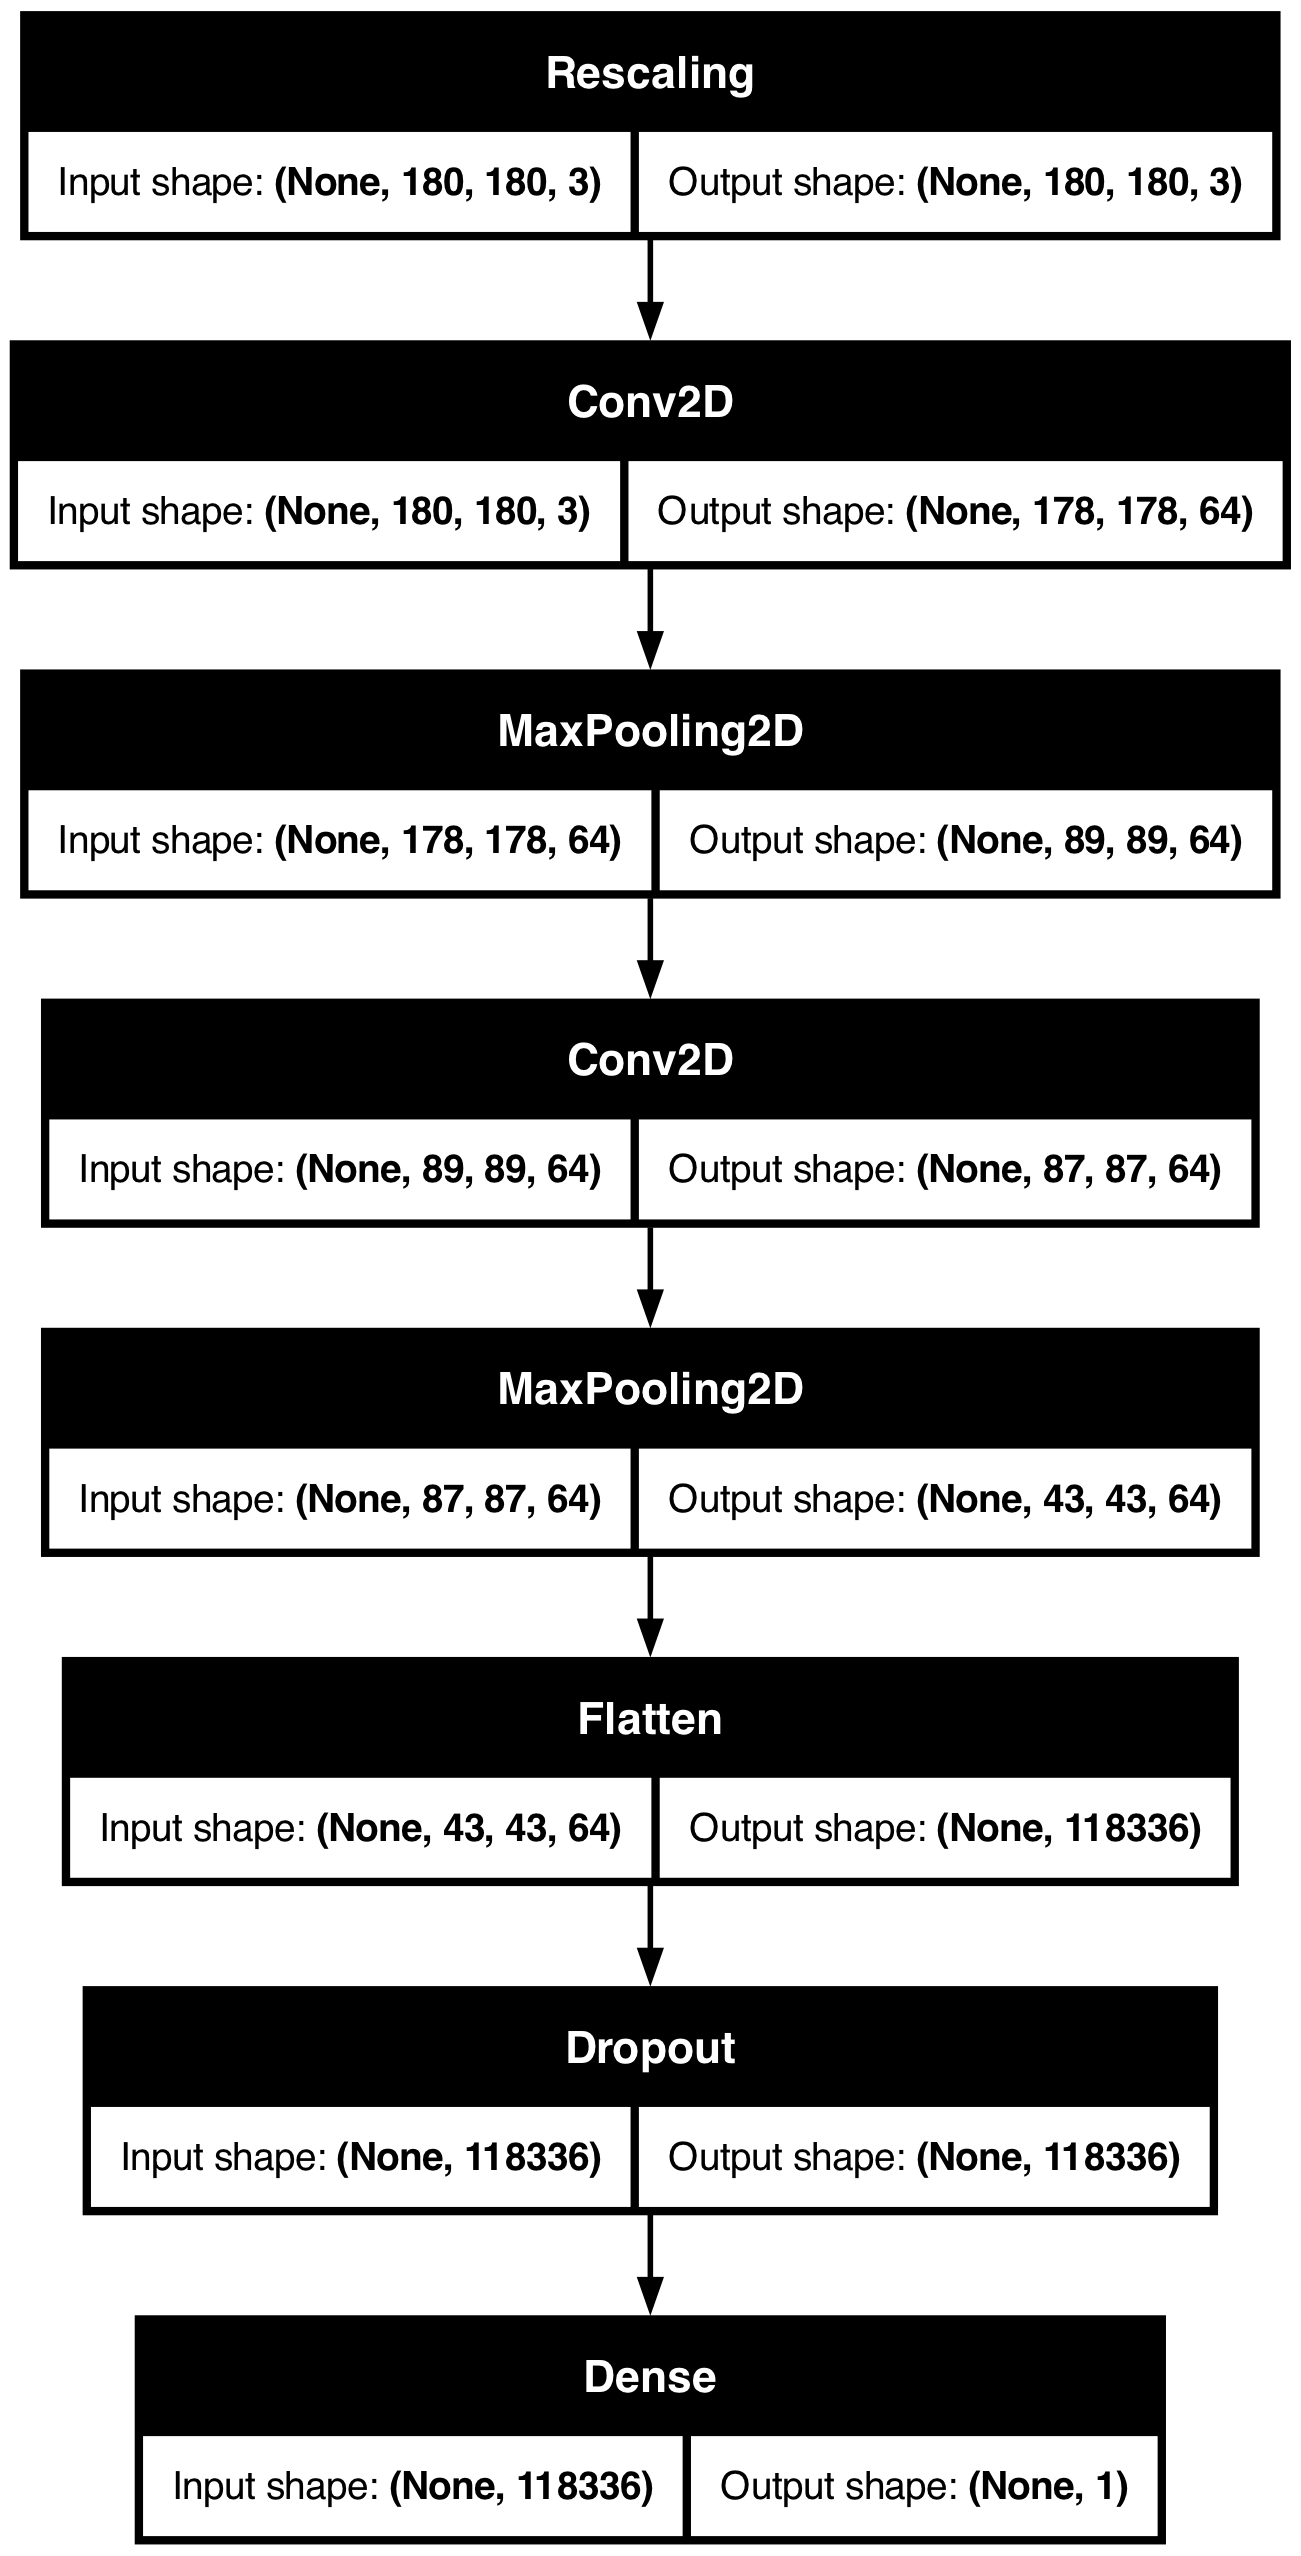

In [14]:
keras.utils.plot_model(sequential_model, show_shapes=True)

In [ ]:
pip install pydot

In [15]:
def make_model(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = keras.layers.Rescaling(1.0 / 255)(inputs)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu")(x)
    x = keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dropout(0.4)(x)
    outputs = keras.layers.Dense(num_classes, activation="sigmoid")(x)

    return keras.Model(inputs, outputs)

functional_model = make_model(image_shape, 1)

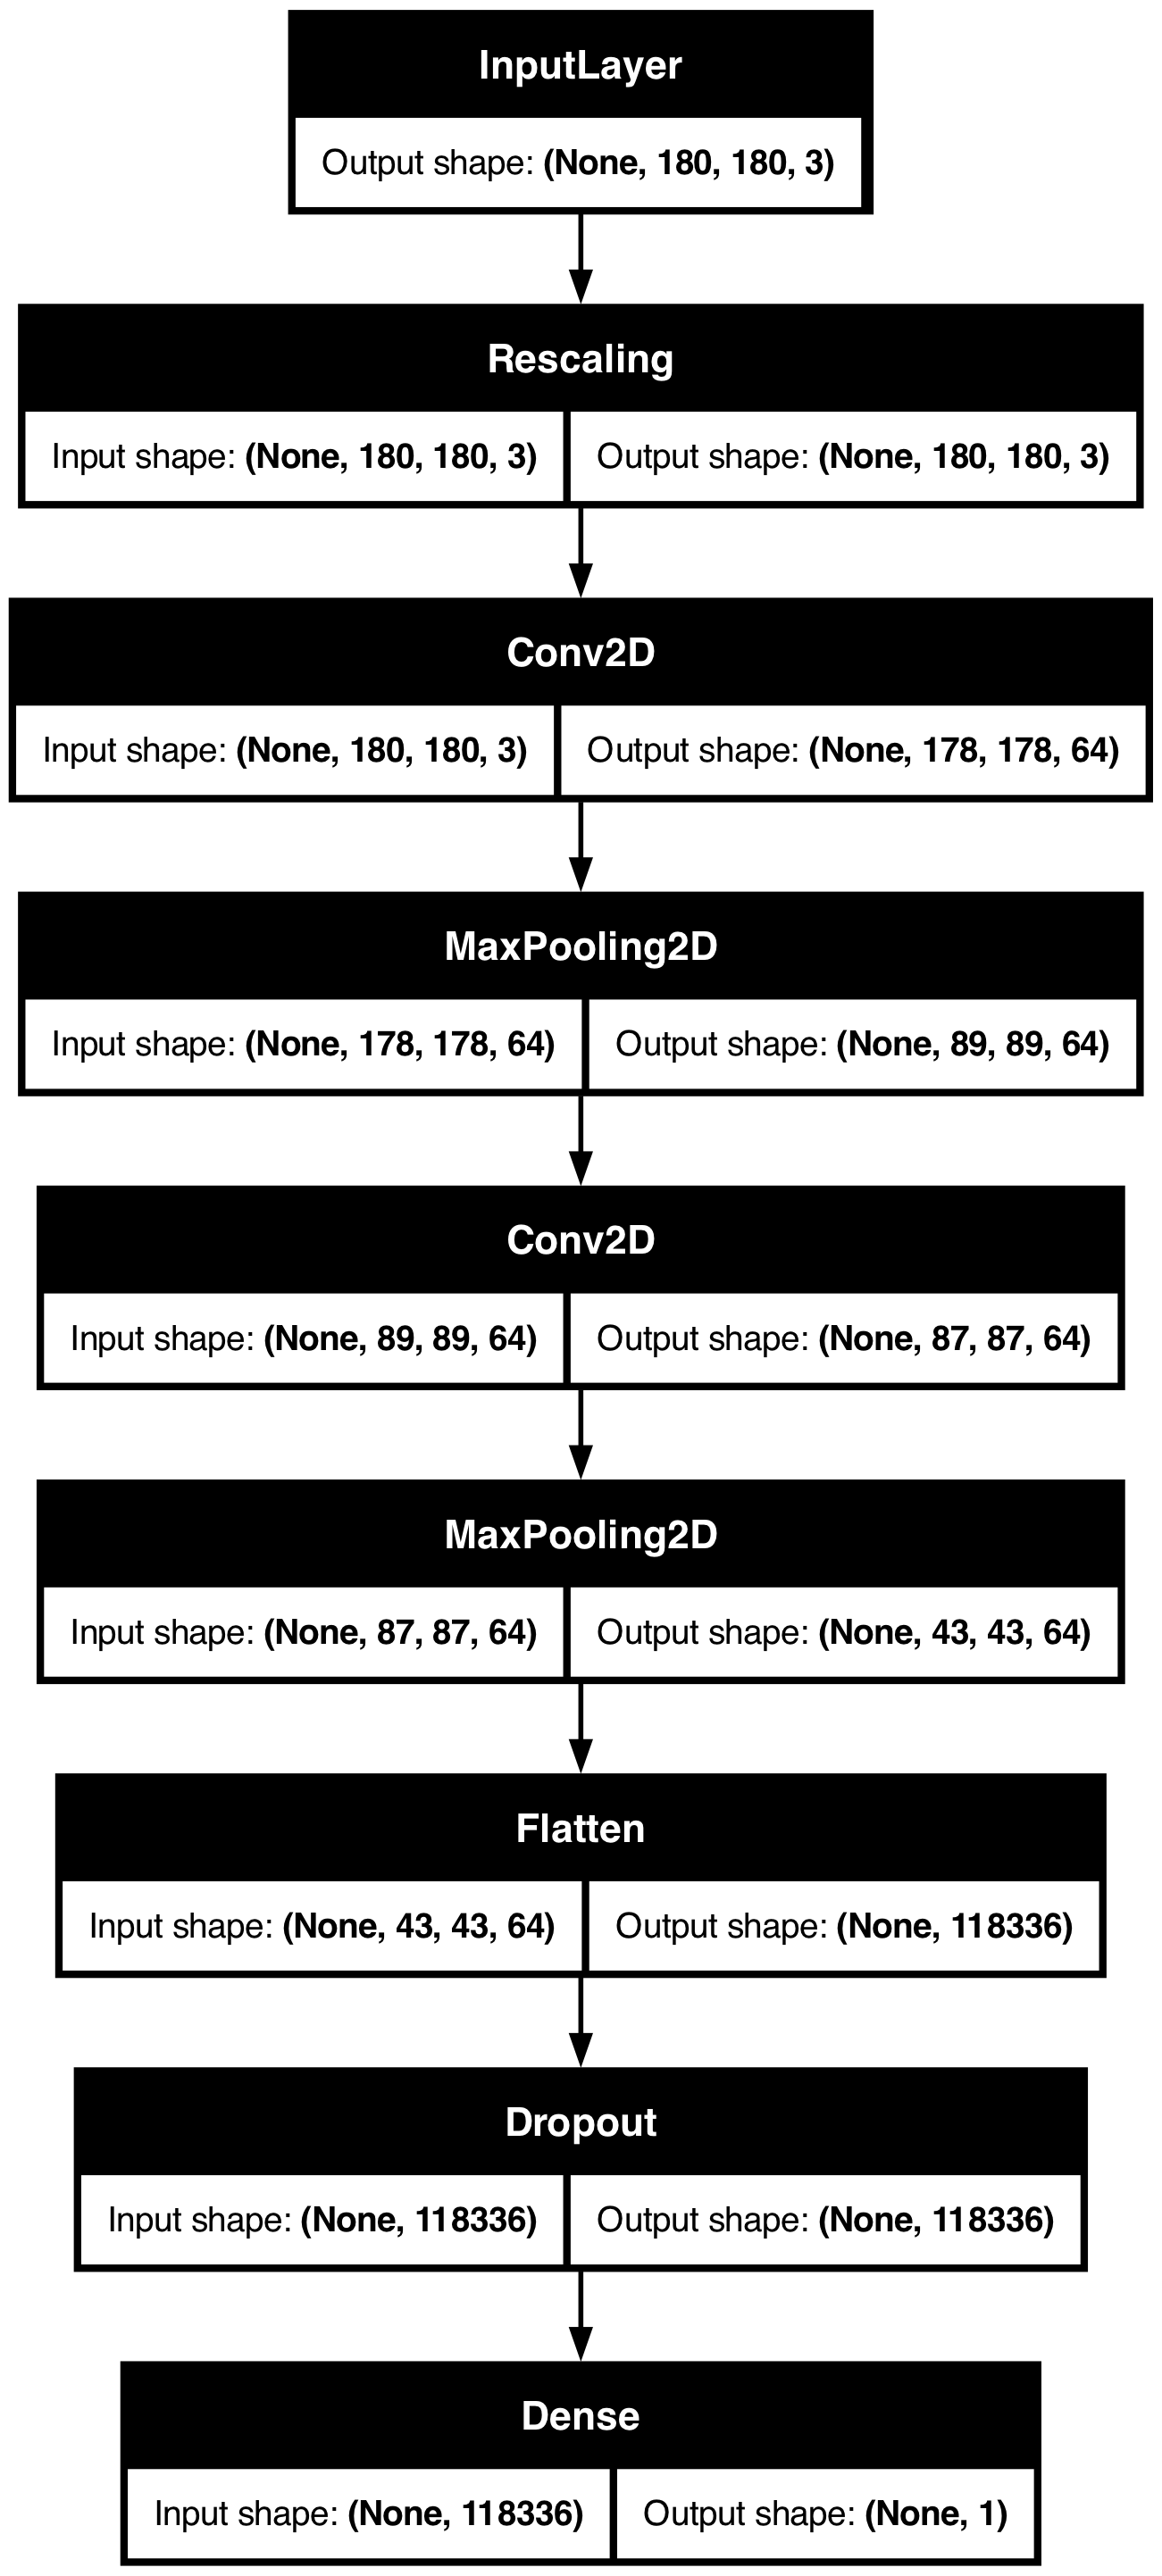

In [16]:
keras.utils.plot_model(functional_model, show_shapes=True)

In [17]:
epochs = 5

functional_model.compile(
    optimizer=keras.optimizers.Adam(3e-4),
    loss="binary_crossentropy",             # notice we use binary_crossentropy (not categorical_crossentropy)
    metrics=["accuracy"],
)
functional_model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
)

Epoch 1/5


Corrupt JPEG data: 2226 extraneous bytes before marker 0xd9


 62/147 ━━━━━━━━━━━━━━━━━━━━ 1:40 1s/step - accuracy: 0.5479 - loss: 0.6828

Corrupt JPEG data: 228 extraneous bytes before marker 0xd9


 70/147 ━━━━━━━━━━━━━━━━━━━━ 1:30 1s/step - accuracy: 0.5511 - loss: 0.6810

...

Corrupt JPEG data: 128 extraneous bytes before marker 0xd9
Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


100/147 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.7041 - loss: 0.5772 

Corrupt JPEG data: 65 extraneous bytes before marker 0xd9


110/147 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.7046 - loss: 0.5767

KeyboardInterrupt: 